**Load Dataset**

In [ ]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

housing = fetch_california_housing()

df = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

df["Price"] = housing.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


**Dataset Information**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


**Missing Values**

In [ ]:
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
Price,0


**Correlation Analysis**

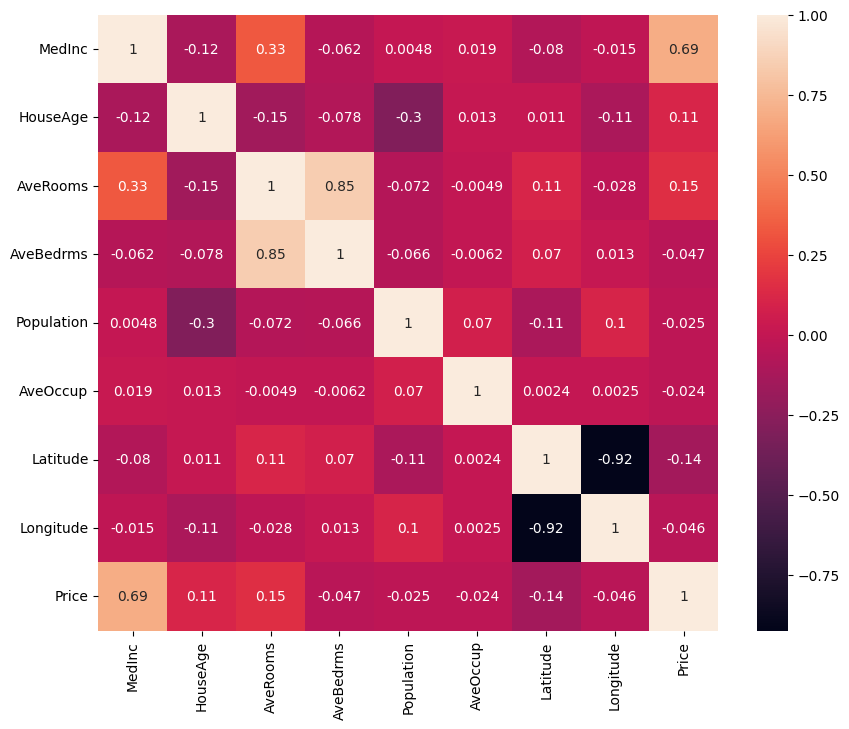

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True)
plt.show()

**Step 3: Train-Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop("Price",axis=1)
y = df["Price"]

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**Step 4: Train Multiple Models**

**Linear Regression**

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train,y_train)

LinearRegression()

**Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train,y_train)

RandomForestRegressor(random_state=42)

**XGBoost**

In [ ]:
from xgboost import XGBRegressor

xgb = XGBRegressor()

xgb.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

**Step 5: Model Evaluatio**n

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

pred = rf.predict(X_test)

print("R2 Score :",r2_score(y_test,pred))
print("MAE :",mean_absolute_error(y_test,pred))

R2 Score : 0.8051230593157366
MAE : 0.32754256845930246


## Linear Regression Model Evaluation

In [ ]:
pred_lr = lr.predict(X_test)

print("Linear Regression R2 Score :", r2_score(y_test, pred_lr))
print("Linear Regression MAE :", mean_absolute_error(y_test, pred_lr))

Linear Regression R2 Score : 0.5757877060324508
Linear Regression MAE : 0.533200130495656


## XGBoost Model Evaluation

In [ ]:
pred_xgb = xgb.predict(X_test)

print("XGBoost R2 Score :", r2_score(y_test, pred_xgb))
print("XGBoost MAE :", mean_absolute_error(y_test, pred_xgb))

XGBoost R2 Score : 0.8301370561019205
XGBoost MAE : 0.30957335413783094


**Step 6: Save Model**

In [ ]:
import joblib

joblib.dump(
    xgb,
    "house_price_model.pkl"
)

['house_price_model.pkl']

**Prediction**

In [ ]:
import joblib
import numpy as np

# Load model
model = joblib.load("house_price_model.pkl")

# New sample
features = np.array([
    [
        8.5,
        15,
        6.2,
        1.1,
        1500,
        3.5,
        37.5,
        -122.0
    ]
])

# Predict
prediction = model.predict(features)

house_price = prediction[0] * 100000

print(f"Predicted House Price: ${house_price:,.2f}")

Predicted House Price: $391,152.75
